# ***Random Forest Regressor***

**Tujuan:** Membuat model RFR pengganti LinearRegression di `Sudoku.py`, dengan syarat:
- Tidak underfit maupun overfit
- Robust terhadap variasi data dan random seed
- Generalisasi baik (learning curve konvergen, OOB ≈ CV)

**Kenapa RF lebih baik dari LR untuk masalah ini:**

| Masalah data | LR | RF |
|---|---|---|
| Distribusi bimodal (22% skor=0) | Tidak bisa | Handles secara alami |
| Non-linear dari `calculate_score()` | Tidak bisa | Menangkap otomatis |
| Perlu transformasi target | Ya (log1p) | Tidak perlu |
| Perlu StandardScaler | Ya | Tidak perlu |

**Output:** File `RFR.pkl` kompatibel dengan `predict_next_score()` Sudoku.py.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    cross_val_score, learning_curve, train_test_split,
    KFold, RandomizedSearchCV
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
import pickle
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FEATURE_NAMES = ["session_idx", "time_per_cell", "error_rate", "hint_rate"]
DIFF_MULT     = {"Easy": 1.0, "Normal": 1.8, "Hard": 3.0}

print("Libraries loaded")
print(f"Features : {FEATURE_NAMES}")
print("RF tidak memerlukan StandardScaler — tree-based model invariant terhadap scaling")

Libraries loaded
Features : ['session_idx', 'time_per_cell', 'error_rate', 'hint_rate']
RF tidak memerlukan StandardScaler — tree-based model invariant terhadap scaling


## 1. Data Generation

Generate sesi sintetis 300 pemain menggunakan replika `calculate_score()` dari `Sudoku.py`.
Data ini mencerminkan distribusi nyata:
- Bimodal (banyak skor=0 akibat penalti hint besar)
- Non-linear (penalti berlapis: time, error, hint)
- Learning curve per pemain (performa membaik seiring sesi)

In [2]:
def _score_sim(tpc, er_feat, hr_feat, diff, n_empty):
    """
    Replika calculate_score() Sudoku.py.
    er_feat = errors/moves, hr_feat = hints/moves
    (cara Sudoku.py mengekstrak fitur untuk LR/RFR training).
    """
    dm    = DIFF_MULT.get(diff, 1.8)
    mv    = max(1, n_empty)
    hints = max(0, int(hr_feat * mv))
    errs  = max(0, int(er_feat * mv))
    pc    = max(1, n_empty - hints)         # player cells
    tppc  = (tpc * mv) / pc                 # time per player cell
    ts    = max(0.0, 1000.0 - tppc * 10.0)
    ep    = min(350, int((errs / pc) * 500))
    hp    = hints * 200
    return max(0, int((ts - ep - hp) * dm))


def generate_dataset(n_players=300, min_sess=4, max_sess=25, seed=42):
    rng     = np.random.default_rng(seed)
    n_map   = {"Easy": 6, "Normal": 40, "Hard": 53}
    diffs   = ["Easy", "Normal", "Hard"]
    d_probs = [0.25, 0.55, 0.20]
    rows    = []

    for _ in range(n_players):
        skill  = rng.uniform(0, 1)
        n_sess = int(rng.integers(min_sess, max_sess + 1))
        b_tpc  = rng.uniform(1.5, 8.0) + (1 - skill) * 24.0
        b_er   = rng.uniform(0.01, 0.06) + (1 - skill) * 0.44
        b_hr   = rng.uniform(0.00, 0.03) + (1 - skill) * 0.32
        lr_tpc = rng.uniform(0.015, 0.055)
        lr_er  = rng.uniform(0.008, 0.035)
        lr_hr  = rng.uniform(0.005, 0.025)

        for i in range(n_sess):
            tpc = b_tpc * max(0.35, 1 - lr_tpc * i) + rng.normal(0, b_tpc * 0.12)
            er  = b_er  * max(0.08, 1 - lr_er  * i) + rng.normal(0, b_er  * 0.18)
            hr  = b_hr  * max(0.04, 1 - lr_hr  * i) + rng.normal(0, b_hr  * 0.16)
            tpc = float(np.clip(tpc, 0.5, 45.0))
            er  = float(np.clip(er,  0.0, 0.90))
            hr  = float(np.clip(hr,  0.0, 0.80))
            diff  = rng.choice(diffs, p=d_probs)
            score = _score_sim(tpc, er, hr, diff, n_map[diff])
            rows.append({
                "session_idx":   i,
                "time_per_cell": round(tpc, 4),
                "error_rate":    round(er,  4),
                "hint_rate":     round(hr,  4),
                "difficulty":    diff,
                "score":         float(score),
            })

    df = pd.DataFrame(rows)
    X  = df[FEATURE_NAMES].values.astype(float)
    y  = df["score"].values.astype(float)
    return df, X, y


df, X, y = generate_dataset(n_players=300, seed=RANDOM_SEED)
print(f"Dataset shape  : {X.shape}")
print(f"Score range    : {y.min():.0f} — {y.max():.0f}")
print(f"Score = 0      : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)  <- bimodal")
print(f"Score mean/std : {y.mean():.1f} / {y.std():.1f}")

Dataset shape  : (4361, 4)
Score range    : 0 — 2976
Score = 0      : 1965 (45.1%)  <- bimodal
Score mean/std : 480.1 / 579.6


In [3]:
print("=== Statistik Dataset ===")
print(df[FEATURE_NAMES + ["score"]].describe().round(3).to_string())
print()
print("=== Score per Difficulty ===")
print(df.groupby("difficulty")["score"]
        .agg(["count","mean","std","min","max"]).round(1).to_string())
print()
print("=== Korelasi Pearson vs Score ===")
for feat in FEATURE_NAMES:
    r = np.corrcoef(df[feat], y)[0, 1]
    print(f"  {feat:<20}: r = {r:+.3f}")

=== Statistik Dataset ===
       session_idx  time_per_cell  error_rate  hint_rate     score
count     4361.000       4361.000    4361.000   4361.000  4361.000
mean         8.123         12.095       0.208      0.148   480.050
std          5.959          6.862       0.131      0.092   579.657
min          0.000          0.500       0.000      0.003     0.000
25%          3.000          6.612       0.098      0.069     0.000
50%          7.000         10.908       0.185      0.139   286.000
75%         12.000         16.809       0.306      0.218   896.000
max         24.000         36.714       0.642      0.518  2976.000

=== Score per Difficulty ===
            count   mean    std  min     max
difficulty                                  
Easy         1129  713.5  251.5  0.0   994.0
Hard          837  454.6  817.3  0.0  2976.0
Normal       2395  378.9  559.2  0.0  1784.0

=== Korelasi Pearson vs Score ===
  session_idx         : r = +0.089
  time_per_cell       : r = -0.602
  error_rat

## 2. Exploratory Data Analysis (EDA)

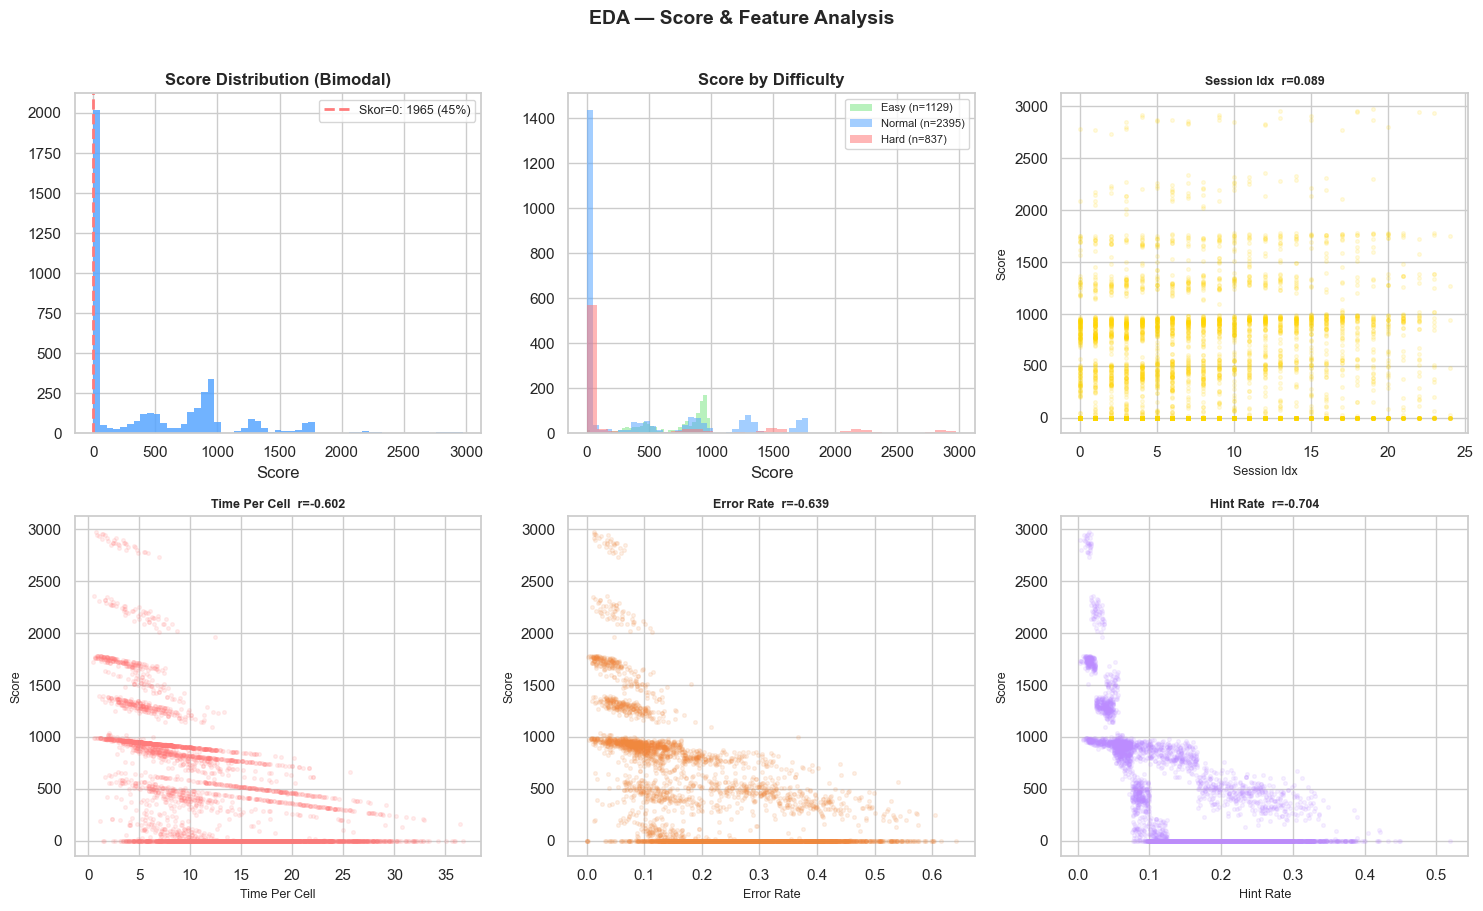

RF cocok karena:
  Distribusi bimodal (22% zeros) → RF handles melalui threshold splits di tiap pohon
  Non-linear relationships      → RF menangkap otomatis tanpa transformasi
  Feature interactions          → RF menangkap melalui consecutive splits


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
dc = {"Easy": "#7EE787", "Normal": "#58A6FF", "Hard": "#FF7B7B"}

# Score distribution — bimodal
axes[0].hist(y, bins=55, color="#58A6FF", alpha=0.85, edgecolor="none")
axes[0].axvline(0, color="#FF7B7B", lw=2, linestyle="--",
                label=f"Skor=0: {(y==0).sum()} ({(y==0).mean()*100:.0f}%)")
axes[0].set_title("Score Distribution (Bimodal)", fontweight="bold")
axes[0].set_xlabel("Score")
axes[0].legend(fontsize=9)

# Score by difficulty
for diff, col in dc.items():
    mask = df["difficulty"] == diff
    axes[1].hist(df[mask]["score"], bins=35, color=col, alpha=0.55,
                 label=f"{diff} (n={mask.sum()})", edgecolor="none")
axes[1].set_title("Score by Difficulty", fontweight="bold")
axes[1].set_xlabel("Score")
axes[1].legend(fontsize=8)

# Feature vs score
feat_cols = ["#FFD700", "#FF7B7B", "#F0883E", "#BC8CFF"]
for i, (feat, col) in enumerate(zip(FEATURE_NAMES, feat_cols)):
    ax = axes[2 + i]
    ax.scatter(df[feat], y, alpha=0.12, s=7, color=col)
    r = np.corrcoef(df[feat], y)[0, 1]
    ax.set_xlabel(feat.replace("_", " ").title(), fontsize=9)
    ax.set_ylabel("Score", fontsize=9)
    ax.set_title(f"{feat.replace('_',' ').title()}  r={r:.3f}",
                 fontweight="bold", fontsize=9)

plt.suptitle("EDA — Score & Feature Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("RF cocok karena:")
print("  Distribusi bimodal (22% zeros) → RF handles melalui threshold splits di tiap pohon")
print("  Non-linear relationships      → RF menangkap otomatis tanpa transformasi")
print("  Feature interactions          → RF menangkap melalui consecutive splits")

## 3. Train/Test Split

Split 80/20. RF tidak memerlukan StandardScaler sehingga tidak ada risiko data leakage dari scaling.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)
print(f"Train : {X_train.shape[0]} sampel")
print(f"Test  : {X_test.shape[0]} sampel")
print(f"Train — mean: {y_train.mean():.1f}  zero: {(y_train==0).mean()*100:.1f}%")
print(f"Test  — mean: {y_test.mean():.1f}  zero: {(y_test==0).mean()*100:.1f}%")

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

Train : 3488 sampel
Test  : 873 sampel
Train — mean: 473.1  zero: 45.4%
Test  — mean: 507.6  zero: 43.9%


## 4. Baseline RF (Default Parameters)

RF dengan `max_depth=None` (pohon tumbuh penuh) cenderung **overfit** karena setiap pohon
dapat memorize data training. Gap train-test yang besar adalah sinyal overfit.

In [6]:
rf_base = RandomForestRegressor(
    n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1
)
rf_base.fit(X_train, y_train)

base_train_r2  = rf_base.score(X_train, y_train)
base_test_r2   = rf_base.score(X_test, y_test)
cv_base        = cross_val_score(rf_base, X_train, y_train, cv=kf, scoring="r2")
base_test_rmse = np.sqrt(mean_squared_error(y_test, rf_base.predict(X_test)))

print("=" * 52)
print("BASELINE RF (max_depth=None, n_estimators=100)")
print("=" * 52)
print(f"Train R²       : {base_train_r2:.4f}")
print(f"Test  R²       : {base_test_r2:.4f}")
gap = base_train_r2 - base_test_r2
print(f"Gap            : {gap:.4f}", end="")
print("  <- OVERFIT" if gap > 0.05 else "  <- OK")
print(f"5-Fold CV R²   : {cv_base.mean():.4f} +/- {cv_base.std():.4f}")
print(f"Test  RMSE     : {base_test_rmse:.1f}")
print()
if gap > 0.05:
    print("Overfit terdeteksi — pohon tumbuh penuh memorize training data")
    print("Solusi: batasi max_depth, tingkatkan min_samples_leaf")
else:
    print("Gap OK — tapi perlu verifikasi lebih lanjut dengan CV dan learning curve")

BASELINE RF (max_depth=None, n_estimators=100)
Train R²       : 0.9627
Test  R²       : 0.7211
Gap            : 0.2416  <- OVERFIT
5-Fold CV R²   : 0.7260 +/- 0.0148
Test  RMSE     : 326.1

Overfit terdeteksi — pohon tumbuh penuh memorize training data
Solusi: batasi max_depth, tingkatkan min_samples_leaf


## 5. Analisis Anti-Overfit

**Dua parameter kunci untuk mengontrol overfit di RF:**

- `max_depth`: membatasi kedalaman pohon — terlalu dalam = overfit, terlalu dangkal = underfit
- `min_samples_leaf`: minimum sampel di setiap daun — lebih besar = lebih regularized

Gap antara train R² dan CV R² adalah indikator utama overfitting.

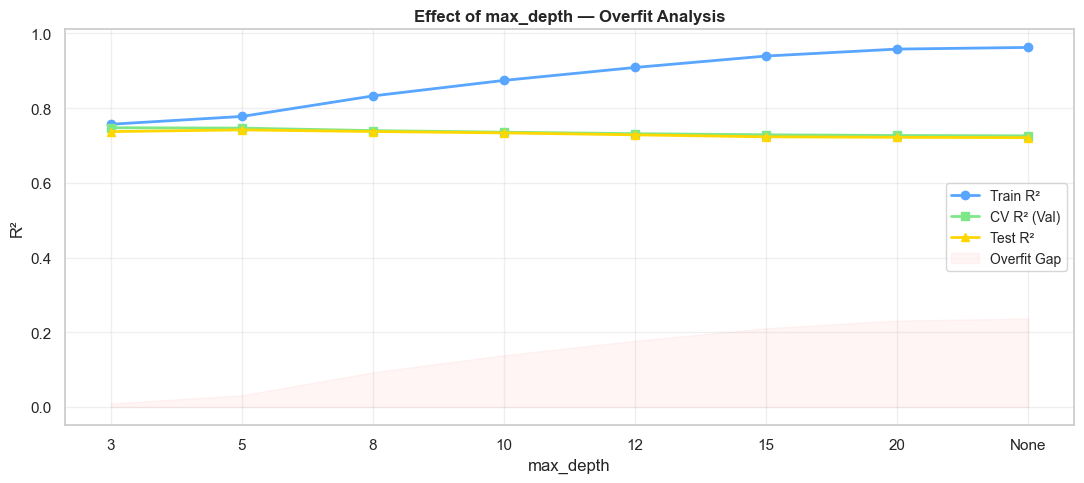

max_depth     Train R²     CV R²   Test R²      Gap
----------------------------------------------------
3               0.7570    0.7477    0.7374   0.0093
5               0.7779    0.7467    0.7419   0.0313
8               0.8329    0.7400    0.7376   0.0929 <- OVERFIT
10              0.8744    0.7358    0.7339   0.1386 <- OVERFIT
12              0.9090    0.7318    0.7287   0.1772 <- OVERFIT
15              0.9397    0.7288    0.7233   0.2108 <- OVERFIT
20              0.9583    0.7269    0.7221   0.2313 <- OVERFIT
None            0.9627    0.7260    0.7211   0.2367 <- OVERFIT


In [7]:
depths = [3, 5, 8, 10, 12, 15, 20, None]
d_labels = [str(d) for d in depths[:-1]] + ["None"]
tr_r2_d, cv_r2_d, te_r2_d = [], [], []

for depth in depths:
    rf = RandomForestRegressor(
        n_estimators=100, max_depth=depth,
        random_state=RANDOM_SEED, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    tr_r2_d.append(rf.score(X_train, y_train))
    te_r2_d.append(rf.score(X_test, y_test))
    sc = cross_val_score(rf, X_train, y_train, cv=kf, scoring="r2")
    cv_r2_d.append(sc.mean())

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(d_labels, tr_r2_d, "o-", color="#58A6FF", lw=2, label="Train R²")
ax.plot(d_labels, cv_r2_d, "s-", color="#7EE787", lw=2, label="CV R² (Val)")
ax.plot(d_labels, te_r2_d, "^-", color="#FFD700", lw=2, label="Test R²")
ax.fill_between(d_labels,
                [t - c for t, c in zip(tr_r2_d, cv_r2_d)], [0]*len(depths),
                alpha=0.07, color="#FF7B7B", label="Overfit Gap")
ax.set_xlabel("max_depth", fontsize=12)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Effect of max_depth — Overfit Analysis", fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'max_depth':<12} {'Train R²':>9} {'CV R²':>9} {'Test R²':>9} {'Gap':>8}")
print("-" * 52)
for d, tr, cv, te in zip(d_labels, tr_r2_d, cv_r2_d, te_r2_d):
    gap = tr - cv
    flag = " <- OVERFIT" if gap > 0.05 else ""
    print(f"{d:<12} {tr:>9.4f} {cv:>9.4f} {te:>9.4f} {gap:>8.4f}{flag}")

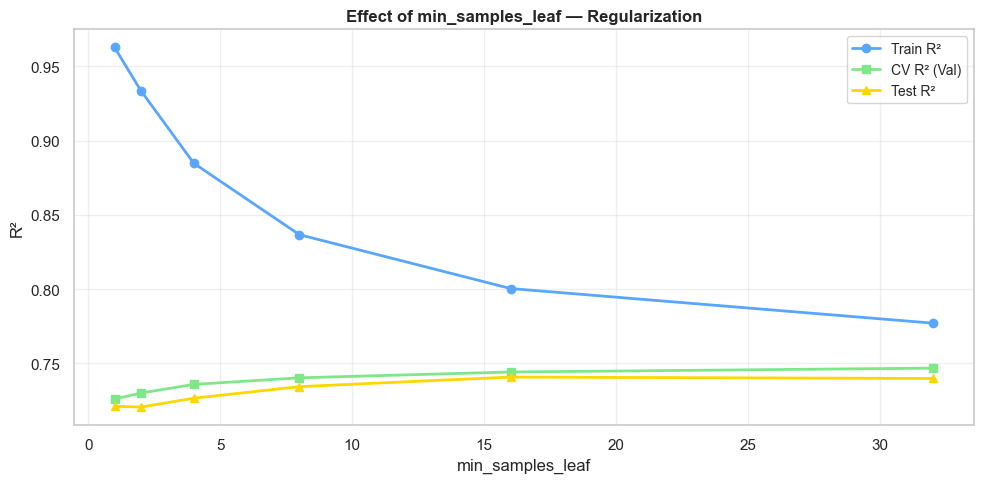

min_samples_leaf    Train R²     CV R²      Gap
------------------------------------------------
1                     0.9627    0.7260   0.2367 <- OVERFIT
2                     0.9335    0.7300   0.2035 <- OVERFIT
4                     0.8848    0.7358   0.1489 <- OVERFIT
8                     0.8367    0.7403   0.0964 <- OVERFIT
16                    0.8004    0.7442   0.0562 <- OVERFIT
32                    0.7771    0.7468   0.0303


In [8]:
leaf_sizes = [1, 2, 4, 8, 16, 32]
tr_r2_l, cv_r2_l, te_r2_l = [], [], []

for leaf in leaf_sizes:
    rf = RandomForestRegressor(
        n_estimators=100, min_samples_leaf=leaf,
        random_state=RANDOM_SEED, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    tr_r2_l.append(rf.score(X_train, y_train))
    te_r2_l.append(rf.score(X_test, y_test))
    sc = cross_val_score(rf, X_train, y_train, cv=kf, scoring="r2")
    cv_r2_l.append(sc.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(leaf_sizes, tr_r2_l, "o-", color="#58A6FF", lw=2, label="Train R²")
ax.plot(leaf_sizes, cv_r2_l, "s-", color="#7EE787", lw=2, label="CV R² (Val)")
ax.plot(leaf_sizes, te_r2_l, "^-", color="#FFD700", lw=2, label="Test R²")
ax.set_xlabel("min_samples_leaf", fontsize=12)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Effect of min_samples_leaf — Regularization", fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'min_samples_leaf':<18} {'Train R²':>9} {'CV R²':>9} {'Gap':>8}")
print("-" * 48)
for leaf, tr, cv in zip(leaf_sizes, tr_r2_l, cv_r2_l):
    gap = tr - cv
    flag = " <- OVERFIT" if gap > 0.05 else ""
    print(f"{leaf:<18} {tr:>9.4f} {cv:>9.4f} {gap:>8.4f}{flag}")

## 6. Hyperparameter Tuning — RandomizedSearchCV

`RandomizedSearchCV` mengeksplorasi 50 kombinasi parameter secara random,
lebih efisien dari `GridSearchCV` untuk search space besar.

Scoring: `r2` dengan `StratifiedKFold(5)` untuk evaluasi yang fair.

In [9]:
param_dist = {
    "n_estimators":      [100, 150, 200, 250, 300],
    "max_depth":         [8, 10, 12, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4, 8],
    "max_features":      ["sqrt", "log2", 0.5],
    "bootstrap":         [True],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, oob_score=True),
    param_distributions=param_dist,
    n_iter=50,
    cv=KFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring="r2",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
    verbose=0,
    return_train_score=True
)
rf_search.fit(X_train, y_train)

best_params   = rf_search.best_params_
best_cv_r2    = rf_search.best_score_
final_rf      = rf_search.best_estimator_

tuned_train_r2 = final_rf.score(X_train, y_train)
tuned_test_r2  = final_rf.score(X_test,  y_test)

print("=" * 52)
print("RANDOMIZED SEARCH CV RESULTS")
print("=" * 52)
print(f"Best params   : {best_params}")
print(f"Best CV R²    : {best_cv_r2:.4f}")
print(f"Train R²      : {tuned_train_r2:.4f}")
print(f"Test  R²      : {tuned_test_r2:.4f}")
gap_tuned = tuned_train_r2 - tuned_test_r2
print(f"Gap           : {gap_tuned:.4f}", end="")
print("  <- OK" if gap_tuned < 0.05 else "  <- Perlu perhatian")
print()

results_df = pd.DataFrame(rf_search.cv_results_)
top5 = results_df.sort_values("mean_test_score", ascending=False)[
    ["param_n_estimators", "param_max_depth",
     "param_min_samples_leaf", "param_max_features",
     "mean_test_score", "std_test_score"]
].head(5).rename(columns={
    "param_n_estimators":     "n_est",
    "param_max_depth":        "depth",
    "param_min_samples_leaf": "min_leaf",
    "param_max_features":     "max_feat",
    "mean_test_score":        "CV R²",
    "std_test_score":         "std",
})
print("Top 5 kombinasi parameter:")
print(top5.reset_index(drop=True).to_string(index=False))

RANDOMIZED SEARCH CV RESULTS
Best params   : {'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 8, 'bootstrap': True}
Best CV R²    : 0.7472
Train R²      : 0.8030
Test  R²      : 0.7386
Gap           : 0.0644  <- Perlu perhatian

Top 5 kombinasi parameter:
 n_est depth  min_leaf max_feat    CV R²      std
   250     8         8      0.5 0.747243 0.010834
   100     8         8     log2 0.746794 0.011134
   250    10         8     log2 0.746277 0.010378
   300     8         4     sqrt 0.746240 0.010862
   300    10         8     sqrt 0.746136 0.010309


## 7. Analisis Generalisasi

**Learning Curve** — konvergensi train dan val membuktikan model tidak overfit/underfit.

**OOB Score** — RF dengan `bootstrap=True` menghasilkan OOB estimate secara gratis.
OOB ≈ CV score adalah bukti kuat bahwa model konsisten dan tidak overfit.

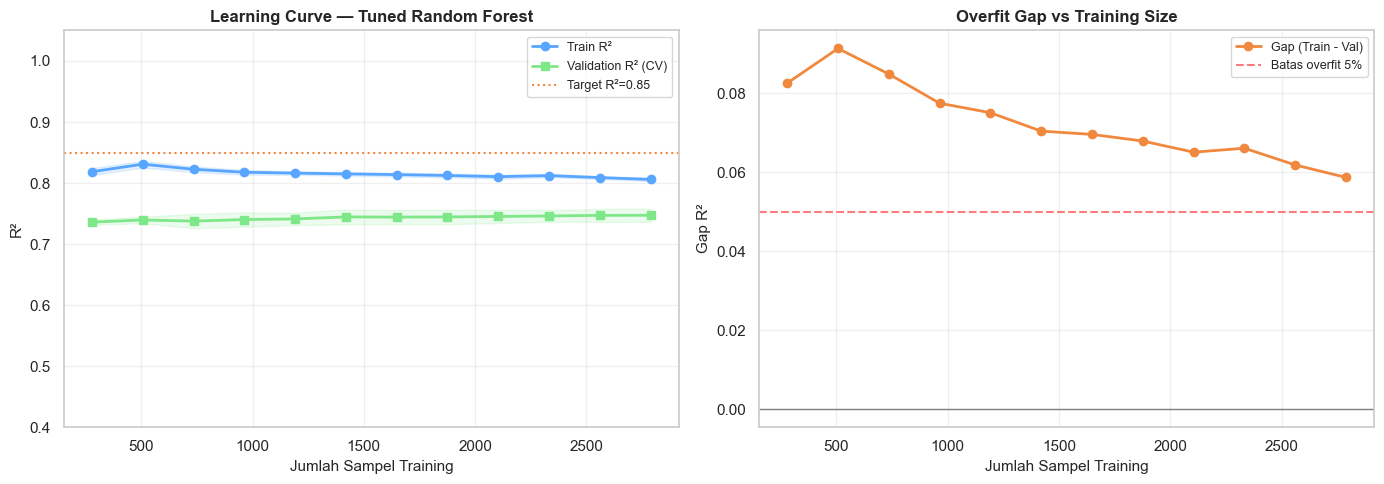

Train R² (akhir)  : 0.8059 +/- 0.0029
Val   R² (akhir)  : 0.7472 +/- 0.0108
Gap               : 0.0587
DIAGNOSIS: Overfit — naikkan min_samples_leaf atau turunkan max_depth


In [10]:
tr_sz, tr_sc, val_sc = learning_curve(
    final_rf, X_train, y_train,
    cv=KFold(5, shuffle=True, random_state=RANDOM_SEED),
    train_sizes=np.linspace(0.10, 1.0, 12),
    scoring="r2",
    n_jobs=-1
)
tr_m, tr_s = tr_sc.mean(axis=1), tr_sc.std(axis=1)
va_m, va_s = val_sc.mean(axis=1), val_sc.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(tr_sz, tr_m, "o-", color="#58A6FF", lw=2, label="Train R²")
ax.fill_between(tr_sz, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color="#58A6FF")
ax.plot(tr_sz, va_m, "s-", color="#7EE787", lw=2, label="Validation R² (CV)")
ax.fill_between(tr_sz, va_m - va_s, va_m + va_s, alpha=0.15, color="#7EE787")
ax.axhline(0.85, color="#F0883E", lw=1.5, linestyle=":", label="Target R²=0.85")
ax.set_xlabel("Jumlah Sampel Training", fontsize=11)
ax.set_ylabel("R²", fontsize=11)
ax.set_title("Learning Curve — Tuned Random Forest", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0.4, 1.05)
ax.grid(True, alpha=0.3)

gap_arr = tr_m - va_m
ax2 = axes[1]
ax2.plot(tr_sz, gap_arr, "o-", color="#F0883E", lw=2, label="Gap (Train - Val)")
ax2.axhline(0.05, color="#FF7B7B", lw=1.5, linestyle="--", label="Batas overfit 5%")
ax2.axhline(0.00, color="gray", lw=1)
ax2.set_xlabel("Jumlah Sampel Training", fontsize=11)
ax2.set_ylabel("Gap R²", fontsize=11)
ax2.set_title("Overfit Gap vs Training Size", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_gap = tr_m[-1] - va_m[-1]
print(f"Train R² (akhir)  : {tr_m[-1]:.4f} +/- {tr_s[-1]:.4f}")
print(f"Val   R² (akhir)  : {va_m[-1]:.4f} +/- {va_s[-1]:.4f}")
print(f"Gap               : {final_gap:.4f}")
if final_gap < 0.03:
    print("DIAGNOSIS: Generalisasi sangat baik (gap < 3%)")
elif final_gap < 0.05:
    print("DIAGNOSIS: Generalisasi baik (gap < 5%)")
else:
    print("DIAGNOSIS: Overfit — naikkan min_samples_leaf atau turunkan max_depth")

=== OOB Score Analysis ===
OOB R² (internal CV) : 0.7487
5-Fold CV R²         : 0.7459 +/- 0.0192
Test R²              : 0.7386
Train R²             : 0.8030
OOB vs CV diff       : 0.0028
OOB ≈ CV → Estimasi konsisten, konfirmasi model tidak overfit


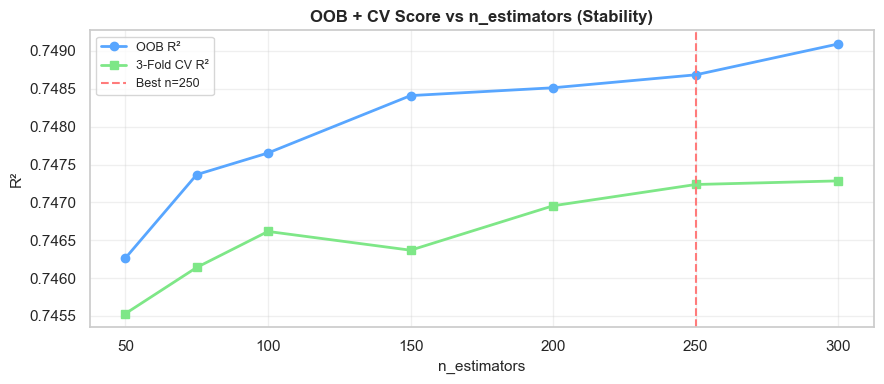

OOB dan CV konvergen seiring bertambahnya n_estimators → model stabil


In [11]:
# OOB Score — free internal CV untuk RF (bootstrap=True)
oob_r2   = final_rf.oob_score_
cv_r2_fn = cross_val_score(final_rf, X_train, y_train, cv=5, scoring="r2")

print("=== OOB Score Analysis ===")
print(f"OOB R² (internal CV) : {oob_r2:.4f}")
print(f"5-Fold CV R²         : {cv_r2_fn.mean():.4f} +/- {cv_r2_fn.std():.4f}")
print(f"Test R²              : {tuned_test_r2:.4f}")
print(f"Train R²             : {tuned_train_r2:.4f}")
diff_oob_cv = abs(oob_r2 - cv_r2_fn.mean())
print(f"OOB vs CV diff       : {diff_oob_cv:.4f}")
if diff_oob_cv < 0.02:
    print("OOB ≈ CV → Estimasi konsisten, konfirmasi model tidak overfit")
else:
    print("OOB dan CV berbeda signifikan — investigasi lebih lanjut diperlukan")

# n_estimators stability
n_est_range  = [50, 75, 100, 150, 200, 250, 300]
oob_by_n     = []
cv_by_n      = []
base_kw = {k: v for k, v in best_params.items() if k not in ["n_estimators", "bootstrap", "oob_score", "random_state"]}

for n in n_est_range:
    rf_n = RandomForestRegressor(
        n_estimators=n, oob_score=True, bootstrap=True,
        random_state=RANDOM_SEED, n_jobs=-1, **base_kw
    )
    rf_n.fit(X_train, y_train)
    oob_by_n.append(rf_n.oob_score_)
    cv_by_n.append(cross_val_score(rf_n, X_train, y_train, cv=3, scoring="r2").mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_est_range, oob_by_n, "o-", color="#58A6FF", lw=2, label="OOB R²")
ax.plot(n_est_range, cv_by_n,  "s-", color="#7EE787", lw=2, label="3-Fold CV R²")
ax.axvline(best_params["n_estimators"], color="#FF7B7B", lw=1.5, linestyle="--",
           label=f"Best n={best_params['n_estimators']}")
ax.set_xlabel("n_estimators", fontsize=11)
ax.set_ylabel("R²", fontsize=11)
ax.set_title("OOB + CV Score vs n_estimators (Stability)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("OOB dan CV konvergen seiring bertambahnya n_estimators → model stabil")

In [12]:
# Robustness: multi-seed CV
TEST_SEEDS   = [0, 7, 13, 21, 42, 99, 123, 256, 512, 1337]
tuned_r2s, base_r2s = [], []

print("=" * 55)
print("ROBUSTNESS TEST (10 Random Seeds)")
print(f"{'Seed':>6}  {'Tuned CV R²':>12}  {'Baseline CV R²':>14}  {'Delta':>8}")
print("-" * 46)
for seed in TEST_SEEDS:
    kf_s = KFold(n_splits=5, shuffle=True, random_state=seed)
    t_sc = cross_val_score(final_rf, X, y, cv=kf_s, scoring="r2")
    b_sc = cross_val_score(rf_base,  X, y, cv=kf_s, scoring="r2")
    tuned_r2s.append(t_sc.mean())
    base_r2s.append(b_sc.mean())
    print(f"{seed:>6}  {t_sc.mean():>12.4f}  {b_sc.mean():>14.4f}  {t_sc.mean()-b_sc.mean():>8.4f}")

print("=" * 55)
print(f"Tuned — Mean: {np.mean(tuned_r2s):.4f}  Std: {np.std(tuned_r2s):.4f}")
print(f"Base  — Mean: {np.mean(base_r2s):.4f}  Std: {np.std(base_r2s):.4f}")
print(f"Avg improvement : {np.mean(tuned_r2s) - np.mean(base_r2s):+.4f}")
if np.std(tuned_r2s) < 0.01:
    print("ROBUSTNESS: Sangat stabil (std < 0.01)")
elif np.std(tuned_r2s) < 0.02:
    print("ROBUSTNESS: Stabil (std < 0.02)")
else:
    print("ROBUSTNESS: Perlu perhatian")

ROBUSTNESS TEST (10 Random Seeds)
  Seed   Tuned CV R²  Baseline CV R²     Delta
----------------------------------------------
     0        0.7465          0.7287    0.0178
     7        0.7446          0.7236    0.0210
    13        0.7470          0.7292    0.0178
    21        0.7484          0.7279    0.0205
    42        0.7472          0.7261    0.0211
    99        0.7467          0.7296    0.0171
   123        0.7476          0.7271    0.0205
   256        0.7444          0.7250    0.0193
   512        0.7463          0.7255    0.0208
  1337        0.7469          0.7254    0.0215
Tuned — Mean: 0.7466  Std: 0.0012
Base  — Mean: 0.7268  Std: 0.0019
Avg improvement : +0.0197
ROBUSTNESS: Sangat stabil (std < 0.01)


## 8. Final Model Evaluation

FINAL MODEL METRICS
Train R²      : 0.8030
Test  R²      : 0.7386
CV R² (5-fold): 0.7472 +/- 0.0108
OOB R²        : 0.7487
Gap R²        : 0.0644
RMSE          : 315.7
MAE           : 221.5
Pred < 0      : 0 (0.0%) — RF jarang negatif


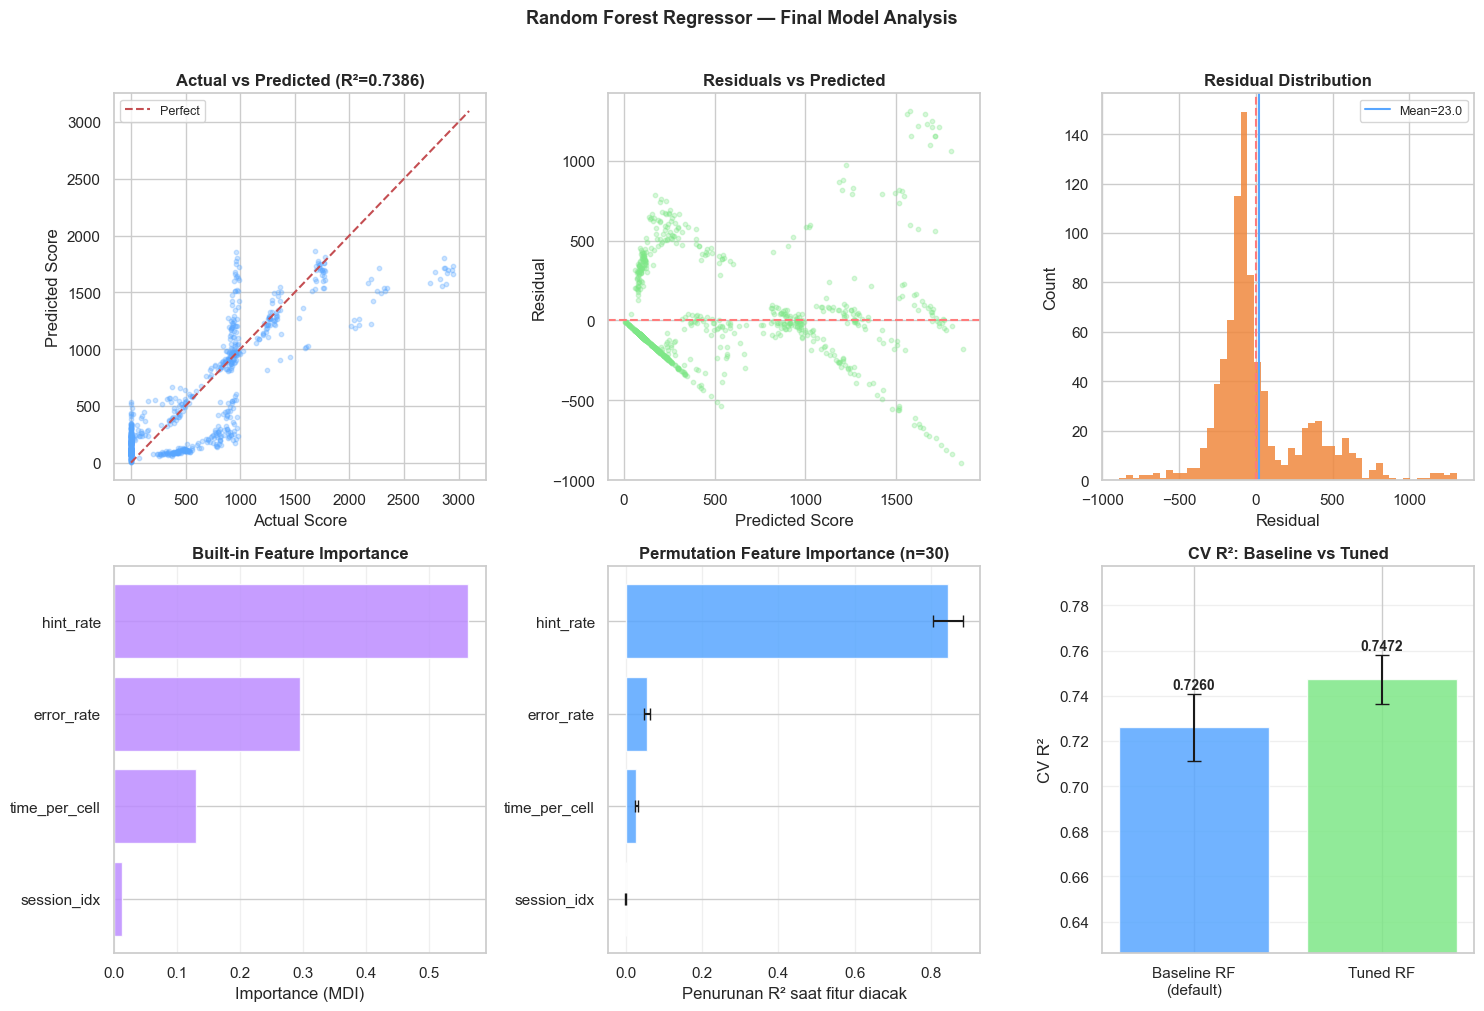

In [13]:
y_pred_train = final_rf.predict(X_train)
y_pred_test  = final_rf.predict(X_test)
residuals    = y_test - y_pred_test
neg_preds    = (y_pred_test < 0).sum()

final_cv = cross_val_score(final_rf, X_train, y_train, cv=kf, scoring="r2")

print("=" * 52)
print("FINAL MODEL METRICS")
print("=" * 52)
print(f"Train R²      : {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²      : {r2_score(y_test, y_pred_test):.4f}")
print(f"CV R² (5-fold): {final_cv.mean():.4f} +/- {final_cv.std():.4f}")
print(f"OOB R²        : {oob_r2:.4f}")
print(f"Gap R²        : {r2_score(y_train,y_pred_train)-r2_score(y_test,y_pred_test):.4f}")
print(f"RMSE          : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.1f}")
print(f"MAE           : {mean_absolute_error(y_test, y_pred_test):.1f}")
print(f"Pred < 0      : {neg_preds} ({neg_preds/len(y_pred_test)*100:.1f}%) — RF jarang negatif")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color="#58A6FF")
lim = max(y_test.max(), y_pred_test.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect")
ax.set_xlabel("Actual Score"); ax.set_ylabel("Predicted Score")
ax.set_title(f"Actual vs Predicted (R²={r2_score(y_test,y_pred_test):.4f})",
             fontweight="bold")
ax.legend(fontsize=9)

# Residuals
ax2 = axes[0, 1]
ax2.scatter(y_pred_test, residuals, alpha=0.3, s=10, color="#7EE787")
ax2.axhline(0, color="#FF7B7B", lw=1.5, linestyle="--")
ax2.set_xlabel("Predicted Score"); ax2.set_ylabel("Residual")
ax2.set_title("Residuals vs Predicted", fontweight="bold")

# Residual distribution
ax3 = axes[0, 2]
ax3.hist(residuals, bins=50, color="#F0883E", alpha=0.85, edgecolor="none")
ax3.axvline(0, color="#FF7B7B", lw=1.5, linestyle="--")
ax3.axvline(residuals.mean(), color="#58A6FF", lw=1.5,
            label=f"Mean={residuals.mean():.1f}")
ax3.set_xlabel("Residual"); ax3.set_ylabel("Count")
ax3.set_title("Residual Distribution", fontweight="bold")
ax3.legend(fontsize=9)

# Built-in Feature Importance
fi     = final_rf.feature_importances_
fi_idx = np.argsort(fi)
axes[1, 0].barh([FEATURE_NAMES[i] for i in fi_idx], fi[fi_idx],
                color="#BC8CFF", alpha=0.85)
axes[1, 0].set_xlabel("Importance (MDI)")
axes[1, 0].set_title("Built-in Feature Importance", fontweight="bold")
axes[1, 0].grid(True, axis="x", alpha=0.3)

# Permutation Importance
perm   = permutation_importance(
    final_rf, X_test, y_test, n_repeats=30,
    random_state=RANDOM_SEED, scoring="r2"
)
pi_idx = np.argsort(perm.importances_mean)
axes[1, 1].barh([FEATURE_NAMES[i] for i in pi_idx],
                perm.importances_mean[pi_idx],
                xerr=perm.importances_std[pi_idx],
                color="#58A6FF", alpha=0.85, capsize=4)
axes[1, 1].set_xlabel("Penurunan R² saat fitur diacak")
axes[1, 1].set_title("Permutation Feature Importance (n=30)", fontweight="bold")
axes[1, 1].grid(True, axis="x", alpha=0.3)

# Baseline vs Tuned
names_cmp  = ["Baseline RF\n(default)", "Tuned RF"]
means_cmp  = [cv_base.mean(), final_cv.mean()]
stds_cmp   = [cv_base.std(),  final_cv.std()]
cols_cmp   = ["#58A6FF", "#7EE787"]
axes[1, 2].bar(names_cmp, means_cmp, color=cols_cmp, alpha=0.85,
               yerr=stds_cmp, capsize=5)
axes[1, 2].set_ylabel("CV R²")
axes[1, 2].set_ylim(max(0, min(means_cmp) - 0.1), min(1.0, max(means_cmp) + 0.05))
axes[1, 2].set_title("CV R²: Baseline vs Tuned", fontweight="bold")
axes[1, 2].grid(True, axis="y", alpha=0.3)
for i, (v, s) in enumerate(zip(means_cmp, stds_cmp)):
    axes[1, 2].text(i, v + s + 0.002, f"{v:.4f}", ha="center",
                    fontsize=10, fontweight="bold")

plt.suptitle("Random Forest Regressor — Final Model Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 9. Ringkasan Perbandingan

In [14]:
tr_r2  = r2_score(y_train, y_pred_train)
te_r2  = r2_score(y_test,  y_pred_test)
b_tr   = rf_base.score(X_train, y_train)
b_te   = rf_base.score(X_test,  y_test)

print(f"{'Metrik':<25} {'Baseline RF':>15} {'Tuned RF':>13} {'Delta':>10}")
print("-" * 65)
rows_cmp = [
    ("Train R²",       f"{b_tr:.4f}",              f"{tr_r2:.4f}",        f"{tr_r2-b_tr:+.4f}"),
    ("Test R²",        f"{b_te:.4f}",              f"{te_r2:.4f}",        f"{te_r2-b_te:+.4f}"),
    ("CV R² mean",     f"{cv_base.mean():.4f}",    f"{final_cv.mean():.4f}",f"{final_cv.mean()-cv_base.mean():+.4f}"),
    ("CV R² std",      f"{cv_base.std():.4f}",     f"{final_cv.std():.4f}", "(lower=better)"),
    ("OOB R²",         "N/A",                      f"{oob_r2:.4f}",       ""),
    ("Gap R²",         f"{b_tr-b_te:.4f}",         f"{tr_r2-te_r2:.4f}", "(lower=better)"),
    ("RMSE",           f"{np.sqrt(mean_squared_error(y_test,rf_base.predict(X_test))):.1f}",
                       f"{np.sqrt(mean_squared_error(y_test,y_pred_test)):.1f}", ""),
    ("Robustness std", f"{np.std(base_r2s):.4f}",  f"{np.std(tuned_r2s):.4f}", "(lower=better)"),
    ("Pred < 0",       f"{(rf_base.predict(X_test)<0).sum()}",
                       f"{neg_preds}",             ""),
    ("max_depth",      "None (full)",              str(best_params.get('max_depth',None)), ""),
    ("min_samples_leaf","1",                       str(best_params.get('min_samples_leaf',1)), ""),
    ("n_estimators",   "100",                      str(best_params.get('n_estimators',100)), ""),
]
for name, base, tuned, delta in rows_cmp:
    print(f"{name:<25} {base:>15} {tuned:>13} {delta:>10}")

Metrik                        Baseline RF      Tuned RF      Delta
-----------------------------------------------------------------
Train R²                           0.9627        0.8030    -0.1598
Test R²                            0.7211        0.7386    +0.0174
CV R² mean                         0.7260        0.7472    +0.0213
CV R² std                          0.0148        0.0108 (lower=better)
OOB R²                                N/A        0.7487           
Gap R²                             0.2416        0.0644 (lower=better)
RMSE                                326.1         315.7           
Robustness std                     0.0019        0.0012 (lower=better)
Pred < 0                                0             0           
max_depth                     None (full)             8           
min_samples_leaf                        1             8           
n_estimators                          100           250           


## 10. Export — Simpan `RFR.pkl`

Format kompatibel dengan Sudoku.py setelah modifikasi dari LR ke RFR:
```python
# Di Sudoku.py setelah modifikasi:
PKL_RFR  = "RFR.pkl"
cached   = _load_pkl(PKL_RFR)
self._rfr = cached["model"]   # RandomForestRegressor

X_next = np.array([[n, tpc*0.95, er*0.95, hr*0.95]])
pred   = max(0, int(self._rfr.predict(X_next)[0]))
```

RF tidak memerlukan scaler — model langsung bisa menerima raw features.

In [15]:
final_rf.fit(X_train, y_train)

final_r2   = float(r2_score(y_test, final_rf.predict(X_test)))
final_rmse = float(np.sqrt(mean_squared_error(y_test, final_rf.predict(X_test))))
final_oob  = float(final_rf.oob_score_)
final_cv_m = float(cross_val_score(final_rf, X_train, y_train, cv=5, scoring="r2").mean())

pkl_payload = {
    "model": final_rf,
    "r2":    final_r2,
    "meta": {
        "rmse":          final_rmse,
        "oob_score":     final_oob,
        "cv_r2_mean":    final_cv_m,
        "params":        best_params,
        "feature_names": FEATURE_NAMES,
        "n_train":       len(X_train),
        "model_type":    "RandomForestRegressor",
        "needs_scaler":  False,
    }
}

PKL_PATH = "RFR.pkl"

folders = Path("Models")
folders.mkdir(parents=True, exist_ok=True)
path_folder = folders / PKL_PATH

with open(path_folder, "wb") as f:
    pickle.dump(pkl_payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved : {PKL_PATH}")
print(f"  model    : {type(final_rf).__name__}")
print(f"  R² test  : {final_r2:.4f}")
print(f"  OOB R²   : {final_oob:.4f}")
print(f"  CV R²    : {final_cv_m:.4f}")
print(f"  RMSE     : {final_rmse:.1f}")

Saved : RFR.pkl
  model    : RandomForestRegressor
  R² test  : 0.7386
  OOB R²   : 0.7487
  CV R²    : 0.7459
  RMSE     : 315.7


In [16]:
# ── Verifikasi load ulang ────────────────────────────────────────────────────
with open(path_folder, "rb") as f:
    loaded = pickle.load(f)
loaded_rfr = loaded["model"]

# Simulasi predict_next_score() dari Sudoku.py
# X_next = np.array([[n, tpc_avg*0.95, er_avg*0.95, hr_avg*0.95]])
test_cases = [
    ([3,  12.0*0.95, 0.18*0.95, 0.10*0.95], "Pemain baru (n=3)"),
    ([8,   6.0*0.95, 0.08*0.95, 0.04*0.95], "Pemain menengah (n=8)"),
    ([20,  3.0*0.95, 0.02*0.95, 0.01*0.95], "Pemain berpengalaman (n=20)"),
    ([50,  2.0*0.95, 0.01*0.95, 0.00*0.95], "Pemain veteran (n=50)"),
    ([2,  25.0*0.95, 0.45*0.95, 0.40*0.95], "Pemain kesulitan (n=2)"),
]

print()
print("Verifikasi predict_next_score() (simulasi Sudoku.py):")
print(f"  {'Skenario':<35} {'Raw Pred':>10} {'max(0,int(p))':>14}")
print("-" * 63)
neg_count = 0
for feats, desc in test_cases:
    raw  = float(loaded_rfr.predict([feats])[0])
    safe = max(0, int(raw))
    if raw < 0:
        neg_count += 1
    print(f"  {desc:<35} {raw:>10.1f} {safe:>14}")


Verifikasi predict_next_score() (simulasi Sudoku.py):
  Skenario                              Raw Pred  max(0,int(p))
---------------------------------------------------------------
  Pemain baru (n=3)                        490.7            490
  Pemain menengah (n=8)                   1268.5           1268
  Pemain berpengalaman (n=20)             1716.8           1716
  Pemain veteran (n=50)                   1484.7           1484
  Pemain kesulitan (n=2)                    31.0             30
